In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2, f_classif
import re

In [2]:
# i.) Loading the dataset
df = pd.read_csv('handwritten/english.csv')

In [3]:
# ii.) EDA & Feature Engineering
# Extract numeric features from filename 'Img/imgXXX-YYY.png'
# XXX -> class_id (The character class)
# YYY -> sample_id (The specific sample number for that character)
def extract_features(path):
    match = re.search(r'Img/img(\d+)-(\d+)', str(path))
    if match:
        return int(match.group(1)), int(match.group(2))
    return 0, 0

df['class_id'], df['sample_id'] = zip(*df['image'].apply(extract_features))
df['path_len'] = df['image'].apply(len)

numeric_features = ['class_id', 'sample_id', 'path_len']

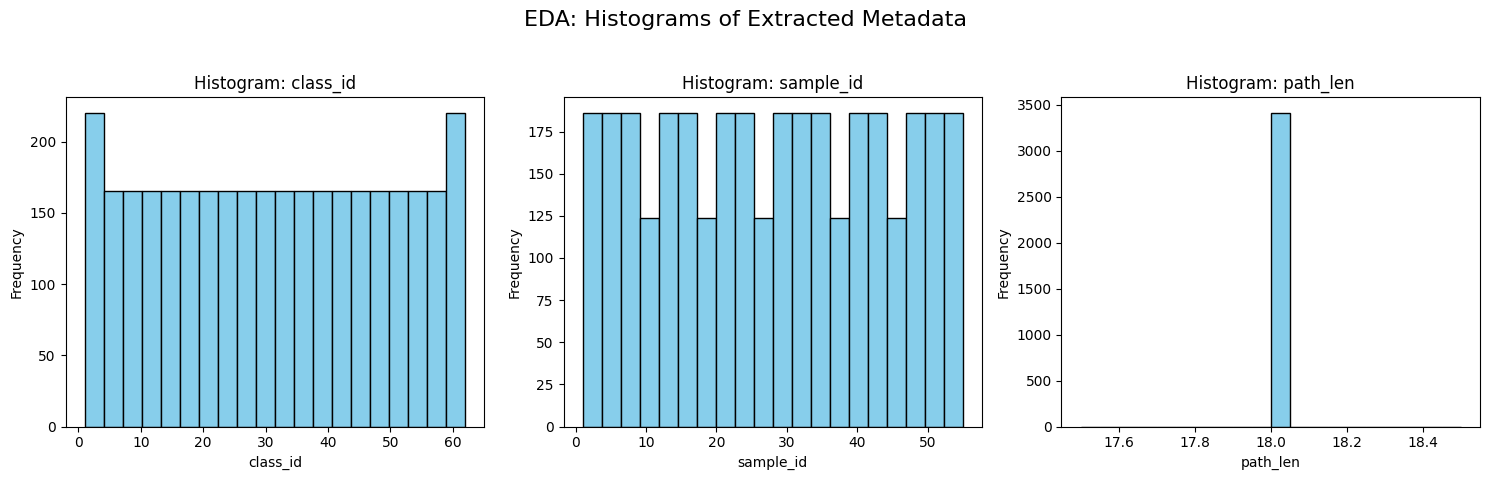

In [4]:
# Grid 1: Histograms (1x3 Grid)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('EDA: Histograms of Extracted Metadata', fontsize=16)
for i, feature in enumerate(numeric_features):
    ax = axes[i]
    # rwidth=1.0 ensures bars touch
    ax.hist(df[feature], bins=20, color='skyblue', edgecolor='black', rwidth=1.0)
    ax.set_title(f'Histogram: {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('english_histograms.eps', format='eps')
plt.show()

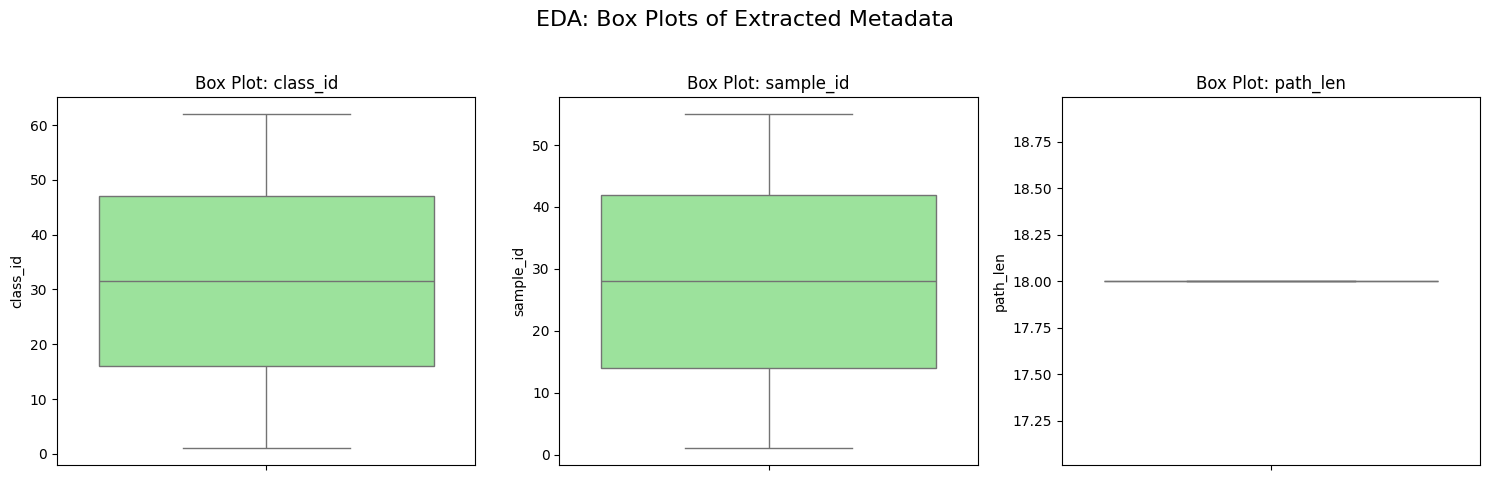

In [5]:
# Grid 2: Box Plots (1x3 Grid)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('EDA: Box Plots of Extracted Metadata', fontsize=16)
for i, feature in enumerate(numeric_features):
    ax = axes[i]
    sns.boxplot(y=df[feature], ax=ax, color='lightgreen')
    ax.set_title(f'Box Plot: {feature}')
    ax.set_ylabel(feature)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('english_boxplots.eps', format='eps')
plt.show()

<Figure size 640x480 with 0 Axes>

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


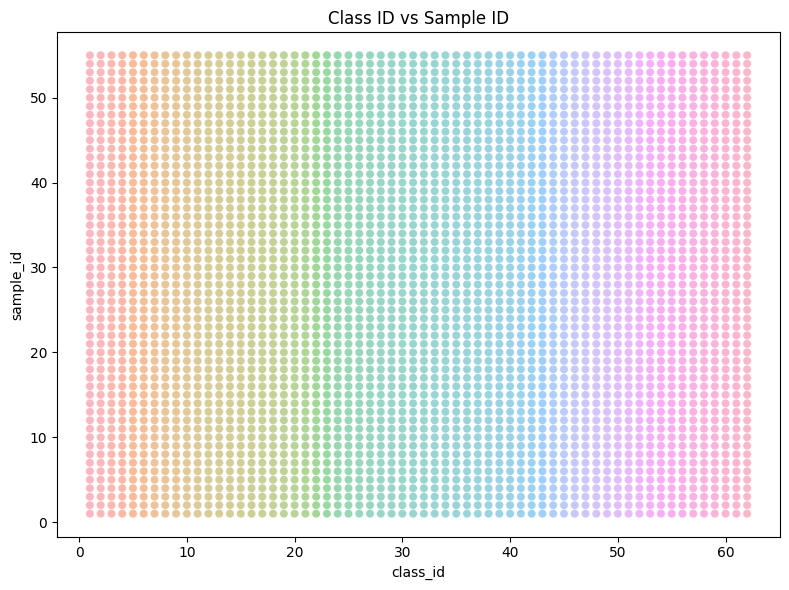

In [6]:
# Bar Chart (Top 20 classes)
top_classes = df['label'].value_counts().nlargest(20)
axes[0].bar(top_classes.index.astype(str), top_classes.values, width=1.0, color='salmon', edgecolor='black')
axes[0].set_title('Top 20 Class Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Heatmap
sns.heatmap(df[numeric_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('english_cat_heat.eps', format='eps')
plt.show()

# Scatter Plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x='class_id', y='sample_id', hue='label', data=df, ax=ax, legend=False, alpha=0.5)
ax.set_title('Class ID vs Sample ID')
plt.tight_layout()
plt.savefig('english_scatter.eps', format='eps')
plt.show()

In [7]:
# iii.) Preprocessing
le = LabelEncoder()
df['label'] = df['label'].astype(str)
df['label_encoded'] = le.fit_transform(df['label'])

X = df[numeric_features]
y = df['label_encoded']

# Standardize (for ANOVA/Splitting)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
X_std_df = pd.DataFrame(X_std, columns=X.columns)

# MinMax (for Chi-Square)
minmax = MinMaxScaler()
X_minmax = minmax.fit_transform(X)
X_minmax_df = pd.DataFrame(X_minmax, columns=X.columns)

In [8]:
# iv.) Feature Selection

# 1. Chi-Square
print("\n--- Chi-Square ---")
chi2_sel = SelectKBest(chi2, k='all')
chi2_sel.fit(X_minmax_df, y)
print(pd.DataFrame({'Feature':X.columns, 'Score':chi2_sel.scores_}).sort_values('Score', ascending=False))

# 2. ANOVA
print("\n--- ANOVA ---")
anova_sel = SelectKBest(f_classif, k='all')
anova_sel.fit(X_std_df, y)
print(pd.DataFrame({'Feature':X.columns, 'Score':anova_sel.scores_}).sort_values('Score', ascending=False))

# v.) Data Splitting
# 70% Train, 15% Val, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(X_std, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\nData Splitting:\nTrain: {X_train.shape}\nVal: {X_val.shape}\nTest: {X_test.shape}")


--- Chi-Square ---
     Feature         Score
0   class_id  5.869672e+02
1  sample_id  2.845636e-27
2   path_len           NaN

--- ANOVA ---
     Feature         Score
1  sample_id -5.638608e-48
0   class_id -2.057832e+17
2   path_len           NaN

Data Splitting:
Train: (2387, 3)
Val: (511, 3)
Test: (512, 3)


c:\Users\raman\Documents\Financial health prediction\MLenv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\raman\Documents\Financial health prediction\MLenv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
